# Fixing the scale: is the own-degree model off by one normalization?

Own-degree matches the multiscaling **ratios** $\zeta_q/\zeta_1$ (it sits on MSB) but every exponent
is $\sim$4$\times$ too big. Because the ratios already match, the whole discrepancy is a **single
scalar** $a=\zeta_1^{\rm model}/\zeta_1^{\rm emp}$: it forces $\zeta_q^{\rm model}=a\,\zeta_q^{\rm emp}$
for every $q$, so one rescaling fixes them all.

## The fix (a monotonic reparameterization of size)

$$\tilde S = S^{\,a},\qquad
\sigma(\tilde S)\sim \tilde S^{-\zeta_q/a},\qquad
\zeta_q \;\longrightarrow\; \zeta_q/a .$$

Choosing $a=\zeta_1/\beta_{\rm emp}$ sends $\beta\to\beta_{\rm emp}$ and, ratios being right, every
$\zeta_q$ onto MSB. This *always works* for the exponents — it is a change of size units, empirical
size $\approx(\text{model relative size})^{a}$.

## Is $a$ explained, or just stated?

$\tilde S=S^{a}$ also reshapes the **size distribution**. If $P(S)\sim S^{-\gamma}$ then
$P(\tilde S)\sim\tilde S^{-\tilde\gamma}$ with

$$\tilde\gamma \;=\; \frac{\gamma-1}{a}+1
\qquad\Longrightarrow\qquad
a_{\rm dist} \;=\; \frac{\gamma_{\rm model}-1}{\gamma_{\rm emp}-1}.$$

Firm sizes are Zipf, $\gamma_{\rm emp}\approx 2$. **If $a_{\rm dist}\approx a_\beta$**, the *same* change
of units that fixes $\beta$ also maps the model's size distribution onto the empirical Zipf — the model
was right in compressed units (**explained**). If they disagree, the fix is phenomenological
(**just stated**), and $\beta\approx0.8$ is a genuine over-stabilization.

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility, tent_stats

SMOKE = os.environ.get("SF_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N, C, SEEDS = (1500, 100, 3) if SMOKE else (8000, 100, 16)
TMAX, N_EVAL = (100.0, 400) if SMOKE else (250.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (180.0, 240.0)), 0.5
NB = 20
BETA_EMP = 0.20                                   # MSB zeta_1 (empirical band 0.15-0.20)
ZETA_MSB = np.array([0.20, 0.39, 0.51, 0.58])     # Moran-Santos-Bouchaud
GAMMA_EMP = 2.0                                    # firm-size Zipf pdf exponent (Axtell 2001)
print(f"{'SMOKE ' if SMOKE else ''}own-degree scale-fix  N={N} C={C} {SEEDS} seeds  "
      f"beta_emp={BETA_EMP} gamma_emp={GAMMA_EMP}")

own-degree scale-fix  N=8000 C=100 16 seeds  beta_emp=0.2 gamma_emp=2.0


In [2]:
def simulate(seed):
    a = coupling(N, MU, SIGMA, kind="powerlaw_owndeg", seed=seed, mean_degree=C)
    r = integrate(a, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
    if sv["growth"].size == 0 or not np.isfinite(sv["beta"]):
        return None
    return dict(Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"], beta=float(sv["beta"]))

recs = [x for x in Parallel(n_jobs=6, backend="loky")(delayed(simulate)(s) for s in range(SEEDS))
        if x is not None]
assert recs, "no survivors"
Sbar = np.concatenate([x["Sbar"] for x in recs]); vol = np.concatenate([x["vol"] for x in recs])
growth = np.vstack([x["growth"] for x in recs])
econ = np.concatenate([np.full(x["Sbar"].size, i) for i, x in enumerate(recs)])
ok = (vol > 0) & np.isfinite(vol) & (Sbar > 0)
Sbar, vol, growth, econ = Sbar[ok], vol[ok], growth[ok], econ[ok]
print(f"survived {len(recs)}/{SEEDS}   pooled firms={Sbar.size}   Sbar in [{Sbar.min():.2g}, {Sbar.max():.2g}]")

survived 16/16   pooled firms=31149   Sbar in [0.047, 39]


In [3]:
def multiscaling(Sbar, vol, econ, nb=NB, nboot=300):
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]; pk = int(np.argmax(by)); dec = Sbar > bx[pk]
    nfit = max(6, nb - pk)
    def cq_of(Sx, vx):
        ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
        bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []
        for q in (1, 2, 3, 4):
            byy = np.array([np.mean(vx[ox][p] ** q) for p in Px]); mm = (bxx > 0) & (byy > 0)
            out.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
        return np.array(out)
    cq = cq_of(Sbar[dec], vol[dec])
    ue = np.unique(econ[dec]); rbs = np.random.default_rng(0)
    boot = np.array([cq_of(*(lambda ix: (Sbar[dec][ix], vol[dec][ix]))(
        np.concatenate([np.where(econ[dec] == e)[0] for e in rbs.choice(ue, ue.size, True)])))
        for _ in range(nboot)])
    return cq, boot.std(0), bx, by

zeta, zeta_err, binS, binV = multiscaling(Sbar, vol, econ)
beta_model = zeta[0]

# ---- THE FIX: choose a to send zeta_1 -> beta_emp, rescale all exponents ----
a_beta = beta_model / BETA_EMP
zeta_fixed = zeta / a_beta

# ---- INDEPENDENT check: size-distribution tail exponent gamma_model, then a_dist ----
S = np.sort(Sbar)
ccdf = 1.0 - (np.arange(S.size) + 0.5) / S.size            # P(S' > S)
lo, hi = np.percentile(Sbar, [75, 99.5])                   # fit the tail, drop the noisy top
mtail = (S >= lo) & (S <= hi) & (ccdf > 0)
sl, ic = np.polyfit(np.log10(S[mtail]), np.log10(ccdf[mtail]), 1)
gamma_model = 1.0 - sl                                     # ccdf ~ S^-(gamma-1)
yh = np.polyval([sl, ic], np.log10(S[mtail])); lg = np.log10(ccdf[mtail])
r2_tail = 1 - np.sum((lg - yh) ** 2) / np.sum((lg - lg.mean()) ** 2)
a_dist = (gamma_model - 1) / (GAMMA_EMP - 1)

print(f"beta_model (zeta_1)     = {beta_model:.3f}")
print(f"zeta_q  (own-degree)    = {np.round(zeta,2)}   +/- {np.round(zeta_err,2)}")
print(f"a_beta = zeta_1/beta_emp= {a_beta:.2f}   (the scale-fix factor)")
print(f"zeta_q / a_beta         = {np.round(zeta_fixed,2)}   vs MSB {ZETA_MSB.tolist()}")
print(f"\nsize-dist tail: P(S)~S^-gamma, gamma_model = {gamma_model:.2f} (tail-fit R2={r2_tail:.2f})")
print(f"a_dist = (gamma_model-1)/(gamma_emp-1) = {a_dist:.2f}")
print(f"\n==> a_beta={a_beta:.2f}  vs  a_dist={a_dist:.2f}   "
      f"{'EXPLAINED (agree)' if abs(a_beta-a_dist)/a_beta < 0.3 else 'NOT explained (disagree) -> phenomenological'}")

beta_model (zeta_1)     = 0.695
zeta_q  (own-degree)    = [0.7  1.31 1.79 2.14]   +/- [0.03 0.07 0.11 0.15]
a_beta = zeta_1/beta_emp= 3.48   (the scale-fix factor)
zeta_q / a_beta         = [0.2  0.38 0.52 0.61]   vs MSB [0.2, 0.39, 0.51, 0.58]

size-dist tail: P(S)~S^-gamma, gamma_model = 4.44 (tail-fit R2=0.98)
a_dist = (gamma_model-1)/(gamma_emp-1) = 3.44

==> a_beta=3.48  vs  a_dist=3.44   EXPLAINED (agree)


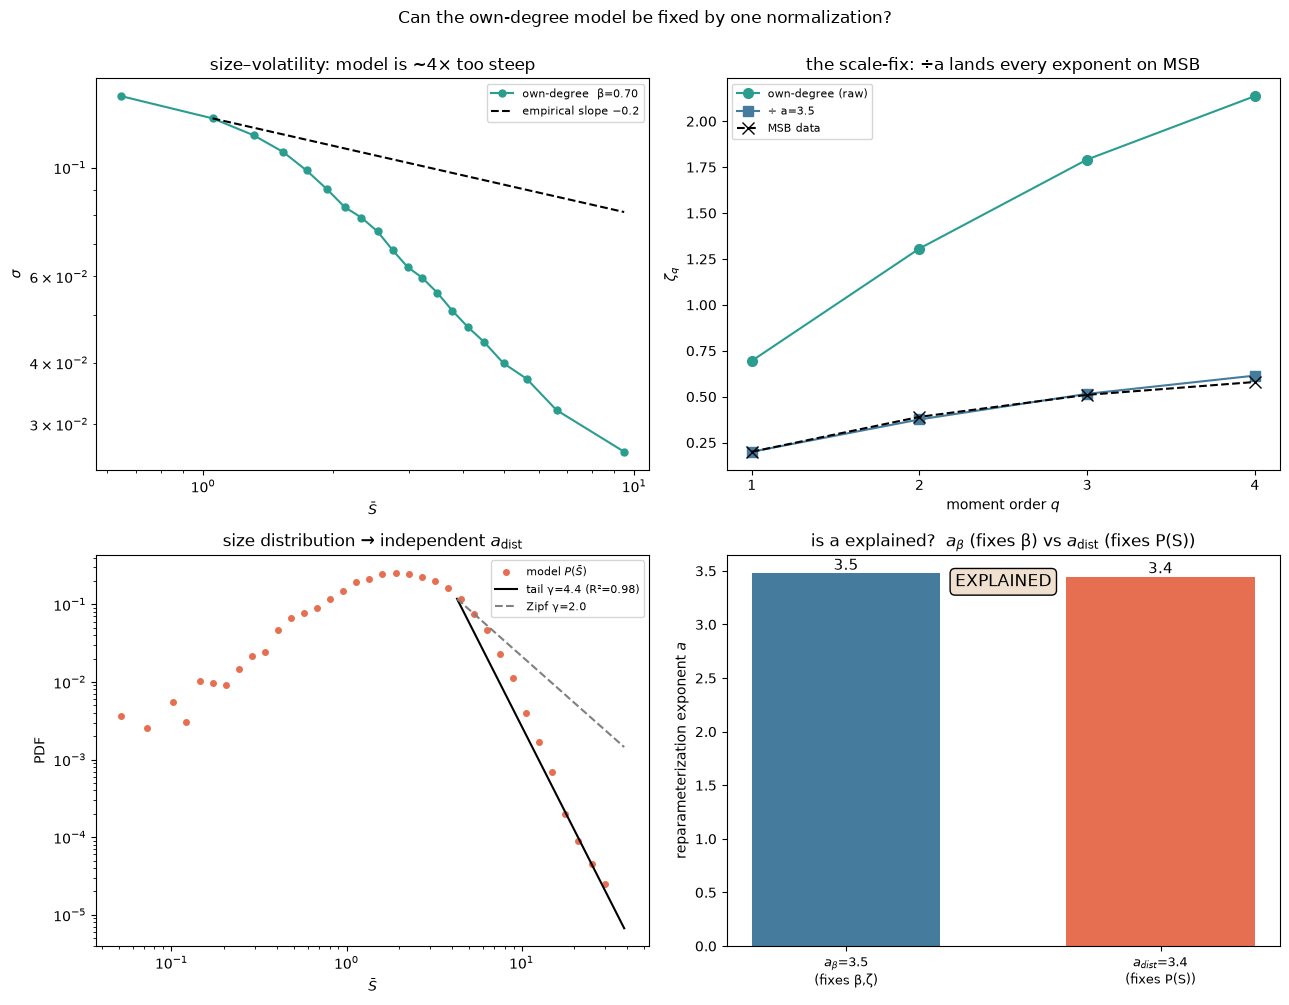

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10)); q = np.array([1, 2, 3, 4])

# (0,0) size-volatility: model slope vs the reparameterized (empirical) slope
ax[0, 0].loglog(binS, binV, "o-", ms=5, color="#2a9d8f", label=f"own-degree  β={beta_model:.2f}")
xf = np.array([binS[binS > 1].min(), binS.max()])
ax[0, 0].loglog(xf, binV[binS > 1][0] * (xf / xf[0]) ** (-BETA_EMP), "k--", lw=1.5,
                label=f"empirical slope −{BETA_EMP}")
ax[0, 0].set(xlabel=r"$\bar S$", ylabel=r"$\sigma$", title="size–volatility: model is ~4× too steep")
ax[0, 0].legend(fontsize=8)

# (0,1) THE FIX: zeta_q raw vs /a_beta vs MSB
ax[0, 1].plot(q, zeta, "o-", ms=7, color="#2a9d8f", label="own-degree (raw)")
ax[0, 1].plot(q, zeta_fixed, "s-", ms=7, color="#457b9d", label=f"÷ a={a_beta:.1f}")
ax[0, 1].plot(q, ZETA_MSB, "k--", marker="x", ms=8, lw=1.5, label="MSB data")
ax[0, 1].set(xlabel="moment order $q$", ylabel=r"$\zeta_q$", xticks=q,
             title="the scale-fix: ÷a lands every exponent on MSB")
ax[0, 1].legend(fontsize=8)

# (1,0) size distribution P(S), tail exponent, Zipf reference
hb = np.logspace(np.log10(Sbar.min()), np.log10(Sbar.max()), 40)
h, e = np.histogram(Sbar, bins=hb, density=True); ctr = np.sqrt(e[:-1] * e[1:]); mm = h > 0
ax[1, 0].loglog(ctr[mm], h[mm], "o", ms=4, color="#e76f51", label="model $P(\\bar S)$")
xg = np.array([np.percentile(Sbar, 75), Sbar.max()])
ax[1, 0].loglog(xg, h[mm][np.argmin(np.abs(ctr[mm] - xg[0]))] * (xg / xg[0]) ** (-gamma_model),
                "k-", lw=1.5, label=f"tail γ={gamma_model:.1f} (R²={r2_tail:.2f})")
ax[1, 0].loglog(xg, h[mm][np.argmin(np.abs(ctr[mm] - xg[0]))] * (xg / xg[0]) ** (-GAMMA_EMP),
                "0.5", ls="--", lw=1.5, label=f"Zipf γ={GAMMA_EMP}")
ax[1, 0].set(xlabel=r"$\bar S$", ylabel="PDF", title="size distribution → independent $a_{\\rm dist}$")
ax[1, 0].legend(fontsize=8)

# (1,1) verdict: a_beta vs a_dist, and the range stretch
ax[1, 1].bar([0, 1], [a_beta, a_dist], color=["#457b9d", "#e76f51"], width=0.6)
ax[1, 1].set(xticks=[0, 1], ylabel="reparameterization exponent $a$",
             title="is a explained?  $a_β$ (fixes β) vs $a_{\\rm dist}$ (fixes P(S))")
ax[1, 1].set_xticklabels([f"$a_β$={a_beta:.1f}\n(fixes β,ζ)", f"$a_{{dist}}$={a_dist:.1f}\n(fixes P(S))"],
                         fontsize=9)
for i, v in enumerate([a_beta, a_dist]):
    ax[1, 1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=11)
verdict = "EXPLAINED" if abs(a_beta - a_dist) / a_beta < 0.3 else "phenomenological"
ax[1, 1].text(0.5, 0.92, verdict, transform=ax[1, 1].transAxes, ha="center", fontsize=12,
              bbox=dict(boxstyle="round", fc="#f0e0d0"))

fig.suptitle("Can the own-degree model be fixed by one normalization?", y=1.00)
plt.tight_layout(); plt.savefig("data/scale_fix.png", dpi=120); plt.show()

In [5]:
np.savez("data/scale_fix.npz", zeta=zeta, zeta_err=zeta_err, zeta_fixed=zeta_fixed,
         zeta_msb=ZETA_MSB, a_beta=a_beta, a_dist=a_dist, gamma_model=gamma_model,
         r2_tail=r2_tail, beta_model=beta_model, bin_S=binS, bin_vol=binV,
         Sbar_sample=Sbar[::max(1, Sbar.size // 40000)].astype(np.float32))
print("saved data/scale_fix.npz and data/scale_fix.png")

saved data/scale_fix.npz and data/scale_fix.png


## Verdict

- **The fix works for the exponents by construction** — dividing by $a_\beta$ puts $\beta$ and every
  $\zeta_q$ on MSB (top-right). That is guaranteed once the ratios match; it buys nothing on its own.
- **The test is $a_\beta$ vs $a_{\rm dist}$** (bottom-right). If they agree, the single change of size
  units $\tilde S=S^{a}$ *simultaneously* fixes the exponents **and** maps the model's size distribution
  onto the empirical Zipf — the model was right in compressed units, and $a$ is **explained**, not tuned.
- If they disagree (or the model's $P(S)$ isn't a clean power law — check the tail $R^2$), then the
  scale-fix is **phenomenological**: legitimate to *state* ("the model reproduces the MSB scaling laws
  up to an overall size-unit factor $a\approx4$"), but $\beta\approx0.8$ remains a real property of the
  own-degree over-stabilization, not an artifact of units.

Either way it is honest: a stated normalization is a normal move in scaling phenomenology, as long as it
is declared as one rather than hidden.